# xarray hands-on

In [2]:
import os
import urllib
import pandas as pd
import numpy as np

import xarray as xr

In [4]:
temp_data = np.array(
    [np.zeros([5, 5]),
    np.ones([5, 5]),
    np.ones([5, 5]) * 2]).astype(int)

temp_data

array([[[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]],

       [[2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2]]])

In [7]:
dims = ('time', 'lat', 'lon')
coords = {
    'time': pd.date_range('2022-09-01', '2022-09-03'),
    'lat': np.arange(70, 20, -10), # Lat/long variables should be strictly increasing or strictly decreasing
    'lon': np.arange(60, 110, 10) # Lat/long variables should be strictly increasing or strictly decreasing
}
attrs = {
    'title': 'temperature across stations',
    'standard_name': 'air_temperature',
    'units': 'degree_c'
}

print(dims)
print(coords)
print(attrs)

('time', 'lat', 'lon')
{'time': DatetimeIndex(['2022-09-01', '2022-09-02', '2022-09-03'], dtype='datetime64[ns]', freq='D'), 'lat': array([70, 60, 50, 40, 30]), 'lon': array([ 60,  70,  80,  90, 100])}
{'title': 'temperature across stations', 'standard_name': 'air_temperature', 'units': 'degree_c'}


In [8]:
# xr.DataArray makes single variable array
temp = xr.DataArray(data = temp_data,
                    dims = dims,
                    coords = coords,
                    attrs = attrs)

temp

<xarray.DataArray (time: 3, lat: 5, lon: 5)> Size: 600B
array([[[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]],

       [[2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2]]])
Coordinates:
  * time     (time) datetime64[ns] 24B 2022-09-01 2022-09-02 2022-09-03
  * lat      (lat) int64 40B 70 60 50 40 30
  * lon      (lon) int64 40B 60 70 80 90 100
Attributes:
    title:          temperature across stations
    standard_name:  air_temperature
    units:          degree_c

In [ ]:
temp.attrs['description'] = 'simple example of xarray'

# Use . notation to access attributes, variables, coordinates, coordinate attributes
temp.lat.attrs = {
    'description': 'latitude',
    'standard_name': 'grid_latitude',
    'units': 'degrees_N'
}

<xarray.DataArray (time: 3, lat: 5, lon: 5)> Size: 600B
array([[[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]],

       [[2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2]]])
Coordinates:
  * time     (time) datetime64[ns] 24B 2022-09-01 2022-09-02 2022-09-03
  * lat      (lat) int64 40B 70 60 50 40 30
  * lon      (lon) int64 40B 60 70 80 90 100
Attributes:
    title:          temperature across stations
    standard_name:  air_temperature
    units:          degree_c
    description:    simple example of xarray

In [ ]:
temp[2, 1, 2] # Index directly on position
temp.loc['2022-09-01', :, :] # Index based on dimension labels
temp.sel(time='2022-09-01', lat = 50) # Index using dimension values, can be any or all in any order
temp.sel(time='2022-09-01', lon=slice(60,80)) # Index using dimension values, slicing
temp.sel(time='2022-09-05', method='nearest') # Index using dimension values choose nearest value if provided value does not exist

<xarray.DataArray (lat: 5, lon: 5)> Size: 200B
array([[2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2]])
Coordinates:
    time     datetime64[ns] 8B 2022-09-03
  * lat      (lat) int64 40B 70 60 50 40 30
  * lon      (lon) int64 40B 60 70 80 90 100
Attributes:
    title:          temperature across stations
    standard_name:  air_temperature
    units:          degree_c
    description:    simple example of xarray

In [ ]:
temp.mean() # Across whole array
temp.mean(dim='time') # Mean over time, get lat/long array with mean over time for each lat/long pair'
temp.mean(dim=('time', 'lat')) # Mean over time and lat, get 1d array with mean over time and latitude for each longitude value

<xarray.DataArray (lon: 5)> Size: 40B
array([1., 1., 1., 1., 1.])
Coordinates:
  * lon      (lon) int64 40B 60 70 80 90 100

In [26]:
# Multi-variable arrays

temp.to_dataset(name = 'temperature') # Convert single variable array to multi-variable array

avg_temp = temp.mean(dim = 'time')

data_vars = {
    'temp': temp,
    'avg_temp': avg_temp
}

attrs = {
    'title': 'temperature data at weather stations',
}

temp_dataset = xr.Dataset(data_vars = data_vars, attrs = attrs)
temp_dataset

<xarray.Dataset> Size: 904B
Dimensions:   (time: 3, lat: 5, lon: 5)
Coordinates:
  * time      (time) datetime64[ns] 24B 2022-09-01 2022-09-02 2022-09-03
  * lat       (lat) int64 40B 70 60 50 40 30
  * lon       (lon) int64 40B 60 70 80 90 100
Data variables:
    temp      (time, lat, lon) int64 600B 0 0 0 0 0 0 0 0 0 ... 2 2 2 2 2 2 2 2
    avg_temp  (lat, lon) float64 200B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
Attributes:
    title:    temperature data at weather stations

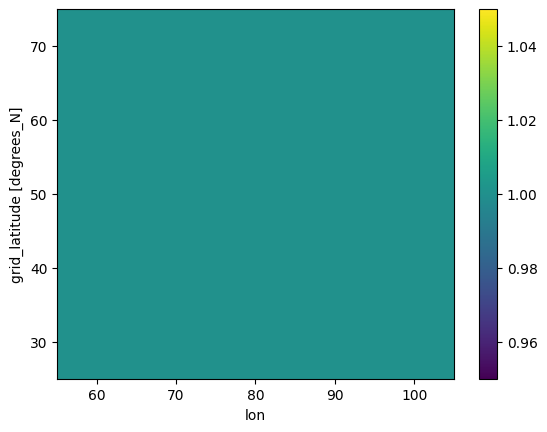

In [28]:
avg_temp.plot()

In [ ]:
# Write out as netCDF

fp = os.path.join(os.getcwd(), 'temp_dataset.nc')

temp_dataset.to_netcdf(fp)

In [ ]:
xr.open_dataset(fp)
check = xr.open_dataset(fp)
check == temp_dataset # Element wise equals
check.equals(temp_dataset) # Checks that a whole array/dataset is equal to another whole array/dataset


True

In [ ]:
temp_dataset.temp.values # Get values only

array([[[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]],

       [[2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2]]])

In [ ]:
url = 'https://arcticdata.io/metacat/d1/mn/v2/object/urn%3Auuid%3A792bfc37-416e-409e-80b1-fdef8ab60033'
msg = urllib.request.urlretrieve(url, "FW_data_CESM_LW_2006_2100.nc")

In [37]:
fw_data = xr.open_dataset('FW_data_CESM_LW_2006_2100.nc')
fw_data

<xarray.Dataset> Size: 135kB
Dimensions:                          (time: 95, member: 11)
Coordinates:
  * time                             (time) float64 760B 2.006e+03 ... 2.1e+03
  * member                           (member) float64 88B 1.0 2.0 ... 10.0 11.0
Data variables: (12/16)
    FW_flux_Fram_annual_net          (time, member) float64 8kB ...
    FW_flux_Barrow_annual_net        (time, member) float64 8kB ...
    FW_flux_Nares_annual_net         (time, member) float64 8kB ...
    FW_flux_Davis_annual_net         (time, member) float64 8kB ...
    FW_flux_BSO_annual_net           (time, member) float64 8kB ...
    FW_flux_Bering_annual_net        (time, member) float64 8kB ...
    ...                               ...
    Solid_FW_flux_BSO_annual_net     (time, member) float64 8kB ...
    Solid_FW_flux_Bering_annual_net  (time, member) float64 8kB ...
    runoff_annual                    (time, member) float64 8kB ...
    netPrec_annual                   (time, member) float64 8kB ...
    Liquid_FW_storage_Arctic_annual  (time, member) float64 8kB ...
    Solid_FW_storage_Arctic_annual   (time, member) float64 8kB ...
Attributes:
    creation_date:   02-Jun-2020 15:38:31
    author:          Alexandra Jahn, CU Boulder, alexandra.jahn@colorado.edu
    title:           Annual timeseries of freshwater data from the CESM Low W...
    description:     Annual mean Freshwater (FW) fluxes and storage relative ...
    data_structure:  The data structure is |Ensemble member | Time (in years)...

In [ ]:
# both work
fw_data.runoff_annual
fw_data['runoff_annual']

# get specific portion of dataset
fw_data.runoff_annual[:, 1] # Get data for the second member only'
fw_data['runoff_annual'].sel(member = 2) # Get data for the second member only'ArithmeticError
fw_data.runoff_annual.sel(member = 2.1, method = 'nearest') # Get data for the second member only

<xarray.DataArray 'runoff_annual' (time: 95)> Size: 760B
[95 values with dtype=float64]
Coordinates:
  * time     (time) float64 760B 2.006e+03 2.007e+03 ... 2.099e+03 2.1e+03
    member   float64 8B 2.0
Attributes:
    units:      km3/yr
    long_name:  FW flux from river runoff into the Arctic Ocean domain, relat...

# Tables <--> Arrays

In [ ]:
temp_pd = pd.read_csv('data/netcdf_temp_data.csv', index_col=[0, 1, 2])
temp_pd.to_xarray()
temp_pd.to_xarray().to_dataframe()

FileNotFoundError: [Errno 2] No such file or directory: 'data/netcdf_temp_data.csv'